# Telecom Italia Heuristic Evaluation — Full 24-Snapshot Analysis

Comparison of **K-Means** and **Analytic** placement heuristics on real-world user
distributions from the Telecom Italia Trentino dataset.

**Design:** 24 snapshots — balanced 4 weeks × 2 day types × 3 hours (10:00, 15:00, 20:00 UTC)
- Weeks: Early Nov (3–4), Mid Nov (9, 14), Late Nov (20, 24), Mid Dec (5, 8)
- Day types: weekday + weekend per week

**Sweep:** N = 1–30 drones, M = 100–800 users (subsampled per seed), R = 20 seeds

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 11

RESULTS_DIR = Path("../results")

METHOD_LABELS  = {"kmeans": "K-Means", "analytic": "Analytic"}
METHOD_COLORS  = {"kmeans": "#0072B2", "analytic": "#E69F00"}
METHOD_MARKERS = {"kmeans": "o",       "analytic": "s"}
METHODS = ["kmeans", "analytic"]

# Load all 24 telecom_full_*.json files
SNAPSHOT_FILES = sorted(RESULTS_DIR.glob("telecom_full_*.json"))
snapshots = {}
for f in SNAPSHOT_FILES:
    data = json.loads(f.read_text())
    # stem e.g. "telecom_full_2013-11-03_h10" -> "2013-11-03_h10"
    stem = f.stem.replace("telecom_full_", "")
    snapshots[stem] = data

print(f"Loaded {len(snapshots)} snapshots")
print(f"M values : {sorted(int(k) for k in next(iter(snapshots.values()))['results_by_m'].keys())}")
_sample = next(iter(next(iter(snapshots.values()))['results_by_m'].values()))
print(f"N values : {sorted(int(k) for k in _sample.keys())}")

Loaded 24 snapshots
M values : [100, 200, 300, 400, 500, 600, 700, 800]
N values : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]


In [2]:
# Build flat DataFrame: one row per (snapshot, m_users, n_drones, method)
rows = []
rows_seed = []
for snap_label, data in snapshots.items():
    for m_str, m_block in data["results_by_m"].items():
        m_users = int(m_str)
        for n_str, block in m_block.items():
            n_drones = int(n_str)
            for method in METHODS:
                if method not in block["methods"]:
                    continue
                avg = block["methods"][method]
                row = {"snapshot": snap_label, "m_users": m_users, "n_drones": n_drones, "method": method}
                row.update(avg)
                rows.append(row)
                for i, sd in enumerate(block["per_seed"][method]):
                    r = {"snapshot": snap_label, "m_users": m_users, "n_drones": n_drones,
                         "method": method, "seed": i}
                    r.update(sd)
                    rows_seed.append(r)

df      = pd.DataFrame(rows)
df_seed = pd.DataFrame(rows_seed)
drone_counts = sorted(df["n_drones"].unique())
user_counts  = sorted(df["m_users"].unique())

print(f"Average results : {len(df):,} rows")
print(f"Per-seed results: {len(df_seed):,} rows")
print(f"Drone counts    : {drone_counts}")
print(f"User counts     : {user_counts}")
df.head()

Average results : 11,520 rows
Per-seed results: 230,400 rows
Drone counts    : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30)]
User counts     : [np.int64(100), np.int64(200), np.int64(300), np.int64(400), np.int64(500), np.int64(600), np.int64(700), np.int64(800)]


,snapshot,m_users,n_drones,method,coverage_pct,throughput_mbps,mean_sinr_db,median_sinr_db,min_sinr_db,sinr_5th_pct_db,total_interference_dbm,worst_pair_interference_dbm,n_users,combined_score,build_time_s
0,2013-11-03_h10,100,1,kmeans,100.00,10218.855371,30.713447,23.935701,12.408100,14.256910,-270.000000,-270.000000,100.0,1.000000,0.004781
1,2013-11-03_h10,100,1,analytic,100.00,12960.346446,39.000974,38.217918,14.393260,18.254677,-270.000000,-270.000000,100.0,1.000000,0.006290
2,2013-11-03_h10,100,2,kmeans,94.40,7575.936475,22.448502,19.257034,0.608970,3.247795,-83.017503,-83.017503,100.0,0.960800,0.003473
3,2013-11-03_h10,100,2,analytic,97.15,8752.965430,26.165609,27.958009,1.119286,5.587256,-83.017503,-83.017503,100.0,0.980050,0.006551
4,2013-11-03_h10,100,3,kmeans,90.70,7069.472890,20.823906,19.648220,-1.202315,1.507083,-65.574238,-66.129942,100.0,0.886658,0.004502


## 1. Coverage vs Drone Count at M=800

Mean coverage across all 24 snapshots with ±1 std shading.
K-Means peaks at N≈8 then collapses; Analytic is stable with crossover at N≈23.

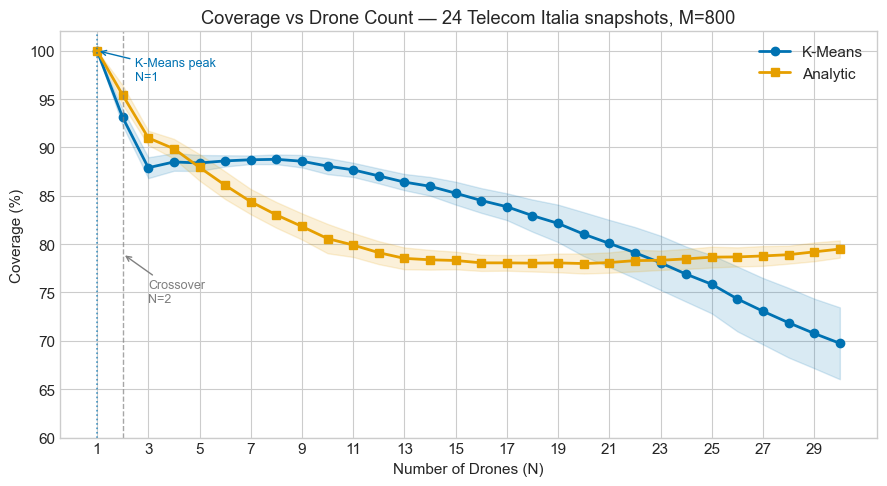

In [3]:
M_MAIN = 800
sub800 = df[df["m_users"] == M_MAIN]

fig, ax = plt.subplots(figsize=(9, 5))

for method in METHODS:
    sub = sub800[sub800["method"] == method].groupby("n_drones")["coverage_pct"]
    mean = sub.mean()
    std  = sub.std()
    ax.plot(mean.index, mean.values, marker=METHOD_MARKERS[method],
            color=METHOD_COLORS[method], label=METHOD_LABELS[method], linewidth=2)
    ax.fill_between(mean.index, mean - std, mean + std,
                    color=METHOD_COLORS[method], alpha=0.15)

# Mark K-Means peak
km_mean = sub800[sub800["method"] == "kmeans"].groupby("n_drones")["coverage_pct"].mean()
peak_n  = km_mean.idxmax()
ax.axvline(peak_n, color="#0072B2", linestyle=":", linewidth=1.2, alpha=0.7)
ax.annotate(f"K-Means peak\nN={peak_n}", xy=(peak_n, km_mean[peak_n]),
            xytext=(peak_n + 1.5, km_mean[peak_n] - 3),
            fontsize=9, color="#0072B2",
            arrowprops=dict(arrowstyle="->", color="#0072B2", lw=1))

# Mark crossover
crossover = (sub800.pivot_table(index="n_drones", columns="method", values="coverage_pct", aggfunc="mean")
             .eval("analytic - kmeans"))
cross_n = crossover[crossover > 0].index.min()
ax.axvline(cross_n, color="gray", linestyle="--", linewidth=1, alpha=0.7)
ax.annotate(f"Crossover\nN={cross_n}", xy=(cross_n, 79), xytext=(cross_n + 1, 74),
            fontsize=9, color="gray",
            arrowprops=dict(arrowstyle="->", color="gray", lw=1))

ax.set_xlabel("Number of Drones (N)")
ax.set_ylabel("Coverage (%)")
ax.set_title(f"Coverage vs Drone Count — 24 Telecom Italia snapshots, M={M_MAIN}")
ax.legend()
ax.set_xticks(range(1, 31, 2))
ax.set_ylim(60, 102)
plt.tight_layout()
plt.savefig("../results/telecom_coverage_vs_N_M800.pdf", bbox_inches="tight")
plt.show()

## 2. Coverage Heatmaps: N × M

One heatmap per method showing mean coverage (%) over 24 snapshots.
Reveals where more drones help vs. hurt at each user density.

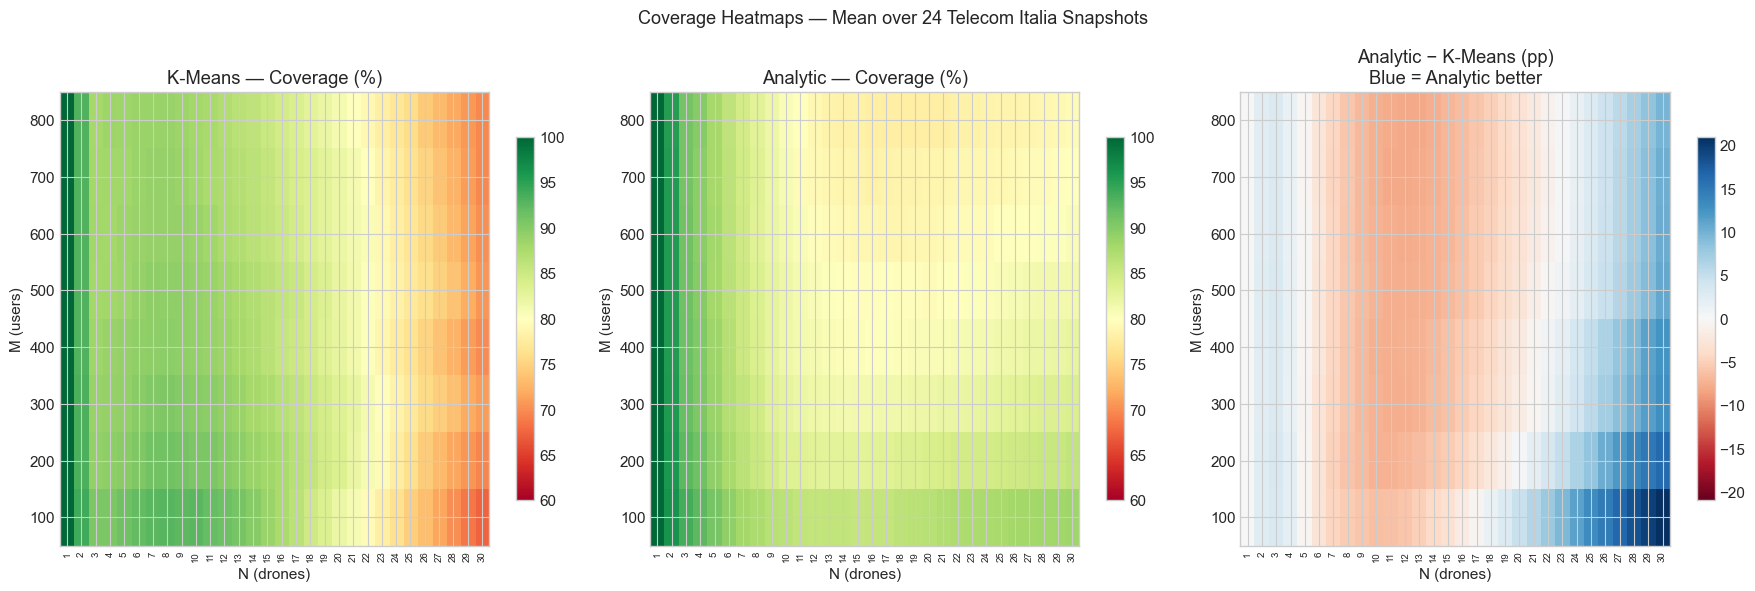

In [4]:
pivot_cov = df.pivot_table(index="n_drones", columns=["method", "m_users"],
                           values="coverage_pct", aggfunc="mean")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, method, title in zip(axes[:2], METHODS, [METHOD_LABELS[m] for m in METHODS]):
    grid = pivot_cov[method].T  # rows=M, cols=N
    im = ax.imshow(grid.values, aspect="auto", origin="lower",
                   cmap="RdYlGn", vmin=60, vmax=100)
    ax.set_xticks(range(len(drone_counts)))
    ax.set_xticklabels(drone_counts, fontsize=7, rotation=90)
    ax.set_yticks(range(len(user_counts)))
    ax.set_yticklabels(user_counts)
    ax.set_xlabel("N (drones)")
    ax.set_ylabel("M (users)")
    ax.set_title(f"{title} — Coverage (%)")
    plt.colorbar(im, ax=ax, shrink=0.8)

# Delta heatmap: Analytic − K-Means
delta_grid = pivot_cov["analytic"].T - pivot_cov["kmeans"].T
lim = max(abs(delta_grid.values.min()), abs(delta_grid.values.max()))
im3 = axes[2].imshow(delta_grid.values, aspect="auto", origin="lower",
                     cmap="RdBu", vmin=-lim, vmax=lim)
axes[2].set_xticks(range(len(drone_counts)))
axes[2].set_xticklabels(drone_counts, fontsize=7, rotation=90)
axes[2].set_yticks(range(len(user_counts)))
axes[2].set_yticklabels(user_counts)
axes[2].set_xlabel("N (drones)")
axes[2].set_ylabel("M (users)")
axes[2].set_title("Analytic − K-Means (pp)\nBlue = Analytic better")
plt.colorbar(im3, ax=axes[2], shrink=0.8)

plt.suptitle("Coverage Heatmaps — Mean over 24 Telecom Italia Snapshots", fontsize=13)
plt.tight_layout()
plt.savefig("../results/telecom_coverage_heatmap_NxM.pdf", bbox_inches="tight")
plt.show()

## 3. Coverage vs M at Fixed Drone Counts

Shows how coverage scales with user load for key fleet sizes.
At small N, one drone saturates quickly; larger N sustains coverage.

/var/folders/4w/qkw3zvms63n038lkf5v326lc0000gn/T/ipykernel_86320/1347209490.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


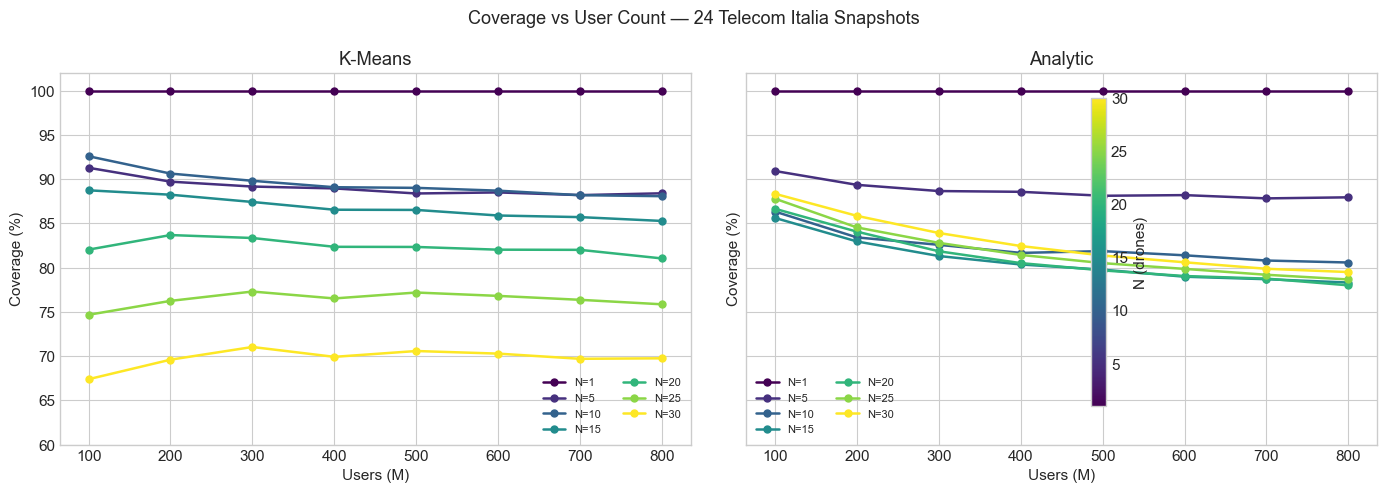

In [5]:
KEY_N = [1, 5, 10, 15, 20, 25, 30]
cmap_n = plt.cm.viridis
norm_n = mcolors.Normalize(vmin=min(KEY_N), vmax=max(KEY_N))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, method in zip(axes, METHODS):
    for n in KEY_N:
        sub = df[(df["method"] == method) & (df["n_drones"] == n)]
        agg = sub.groupby("m_users")["coverage_pct"].mean()
        color = cmap_n(norm_n(n))
        ax.plot(agg.index, agg.values, marker="o", markersize=5,
                color=color, label=f"N={n}", linewidth=1.8)
    ax.set_xlabel("Users (M)")
    ax.set_ylabel("Coverage (%)")
    ax.set_title(METHOD_LABELS[method])
    ax.set_xticks(user_counts)
    ax.set_ylim(60, 102)
    ax.legend(fontsize=8, ncol=2)

sm = plt.cm.ScalarMappable(cmap=cmap_n, norm=norm_n)
sm.set_array([])
fig.colorbar(sm, ax=axes, label="N (drones)", shrink=0.8)
plt.suptitle("Coverage vs User Count — 24 Telecom Italia Snapshots", fontsize=13)
plt.tight_layout()
plt.savefig("../results/telecom_coverage_vs_M.pdf", bbox_inches="tight")
plt.show()

## 4. Combined Score and Interference vs N at M=800

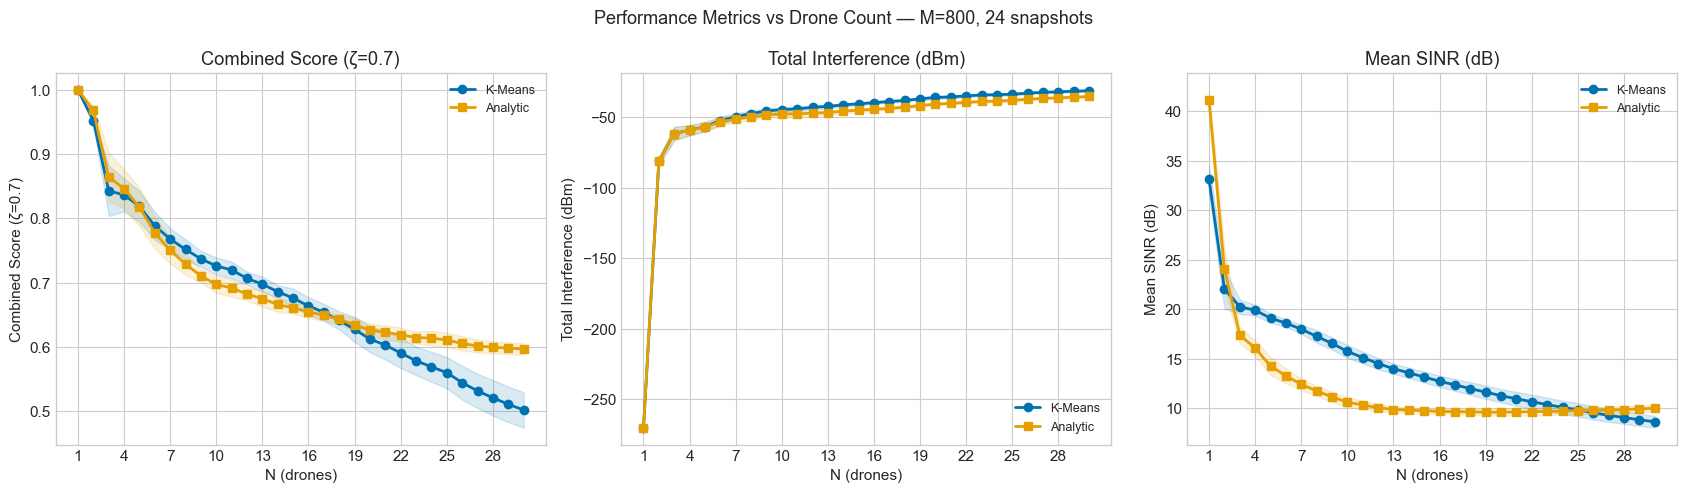

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

metrics = [
    ("combined_score",          "Combined Score (ζ=0.7)", True),
    ("total_interference_dbm",  "Total Interference (dBm)", False),
    ("mean_sinr_db",            "Mean SINR (dB)", True),
]

for ax, (col, title, higher_better) in zip(axes, metrics):
    for method in METHODS:
        sub = sub800[sub800["method"] == method].groupby("n_drones")[col]
        mean = sub.mean()
        std  = sub.std()
        ax.plot(mean.index, mean.values, marker=METHOD_MARKERS[method],
                color=METHOD_COLORS[method], label=METHOD_LABELS[method], linewidth=2)
        ax.fill_between(mean.index, mean - std, mean + std,
                        color=METHOD_COLORS[method], alpha=0.15)
    ax.set_xlabel("N (drones)")
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.set_xticks(range(1, 31, 3))
    ax.legend(fontsize=9)

plt.suptitle(f"Performance Metrics vs Drone Count — M={M_MAIN}, 24 snapshots", fontsize=13)
plt.tight_layout()
plt.savefig("../results/telecom_metrics_vs_N_M800.pdf", bbox_inches="tight")
plt.show()

## 5. Per-Seed Variability at M=800

Box plots of coverage across 20 seeds for each snapshot at N=5 and N=25,
showing that the patterns are robust to K-Means initialisation noise.

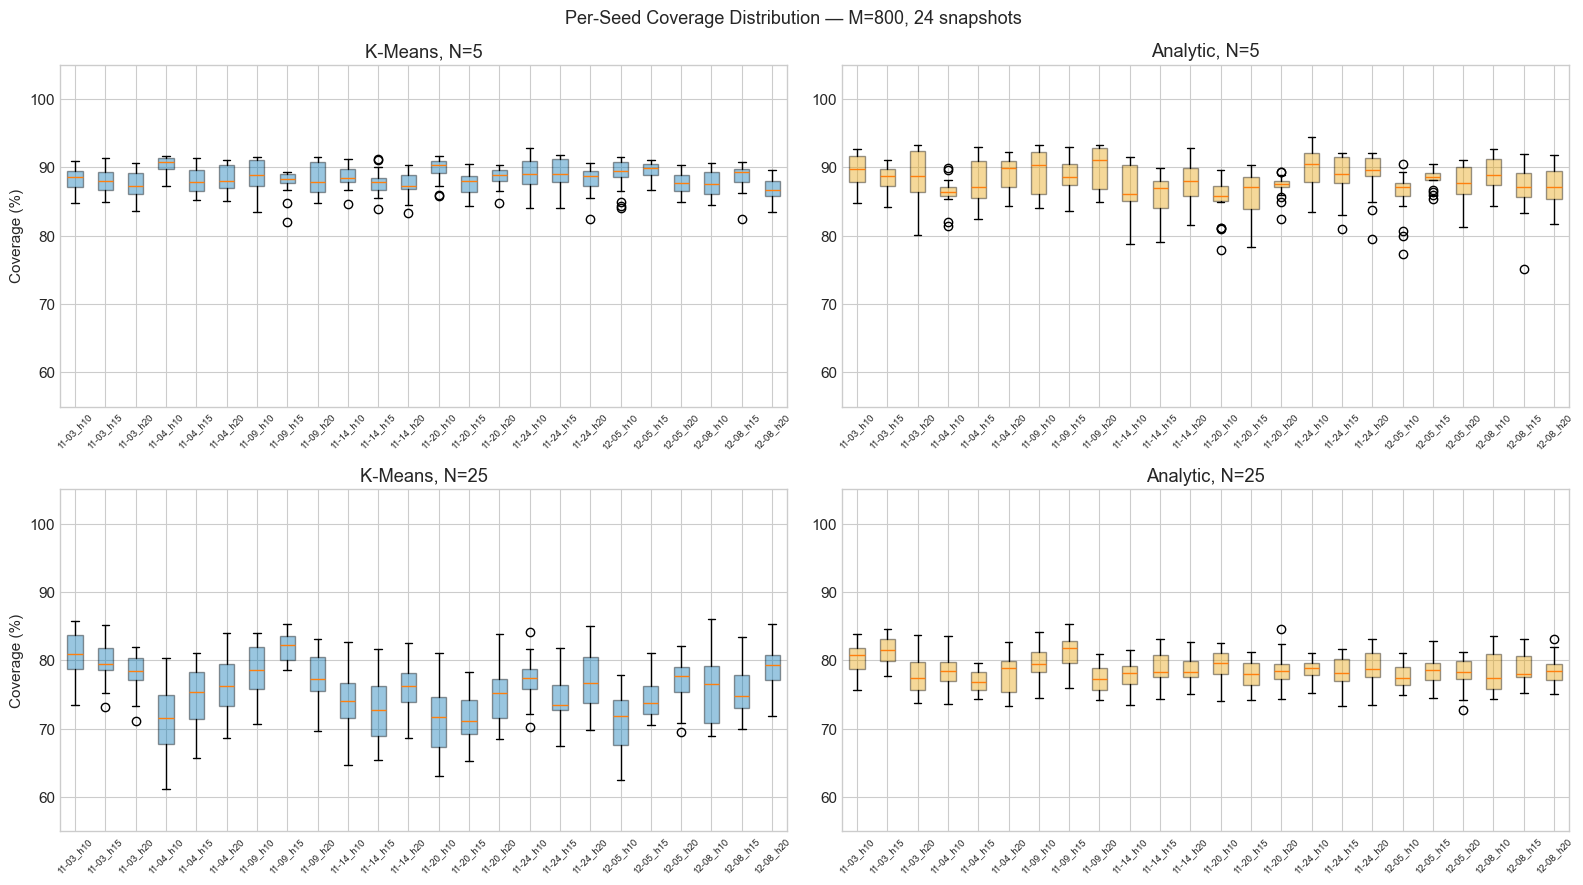

In [7]:
seed800 = df_seed[df_seed["m_users"] == M_MAIN]
snap_labels = sorted(seed800["snapshot"].unique())
short_labels = [s.replace("2013-", "") for s in snap_labels]

fig, axes = plt.subplots(2, 2, figsize=(16, 9))

for row_idx, n_drones in enumerate([5, 25]):
    for col_idx, method in enumerate(METHODS):
        ax = axes[row_idx, col_idx]
        sub = seed800[(seed800["n_drones"] == n_drones) & (seed800["method"] == method)]
        data = [sub[sub["snapshot"] == s]["coverage_pct"].values for s in snap_labels]
        bp = ax.boxplot(data, tick_labels=short_labels, patch_artist=True)
        for patch in bp["boxes"]:
            patch.set_facecolor(METHOD_COLORS[method])
            patch.set_alpha(0.4)
        ax.set_title(f"{METHOD_LABELS[method]}, N={n_drones}")
        ax.set_ylabel("Coverage (%)" if col_idx == 0 else "")
        ax.tick_params(axis="x", rotation=45, labelsize=7)
        ax.set_ylim(55, 105)

plt.suptitle(f"Per-Seed Coverage Distribution — M={M_MAIN}, 24 snapshots", fontsize=13)
plt.tight_layout()
plt.savefig("../results/telecom_seed_variability.pdf", bbox_inches="tight")
plt.show()

## 6. Coverage vs N by Date Group (Small Multiples, M=800)

8 panels — one per date — each showing 3 hours as separate lines.
Reveals which dates/hours are most affected by fleet-size degradation.

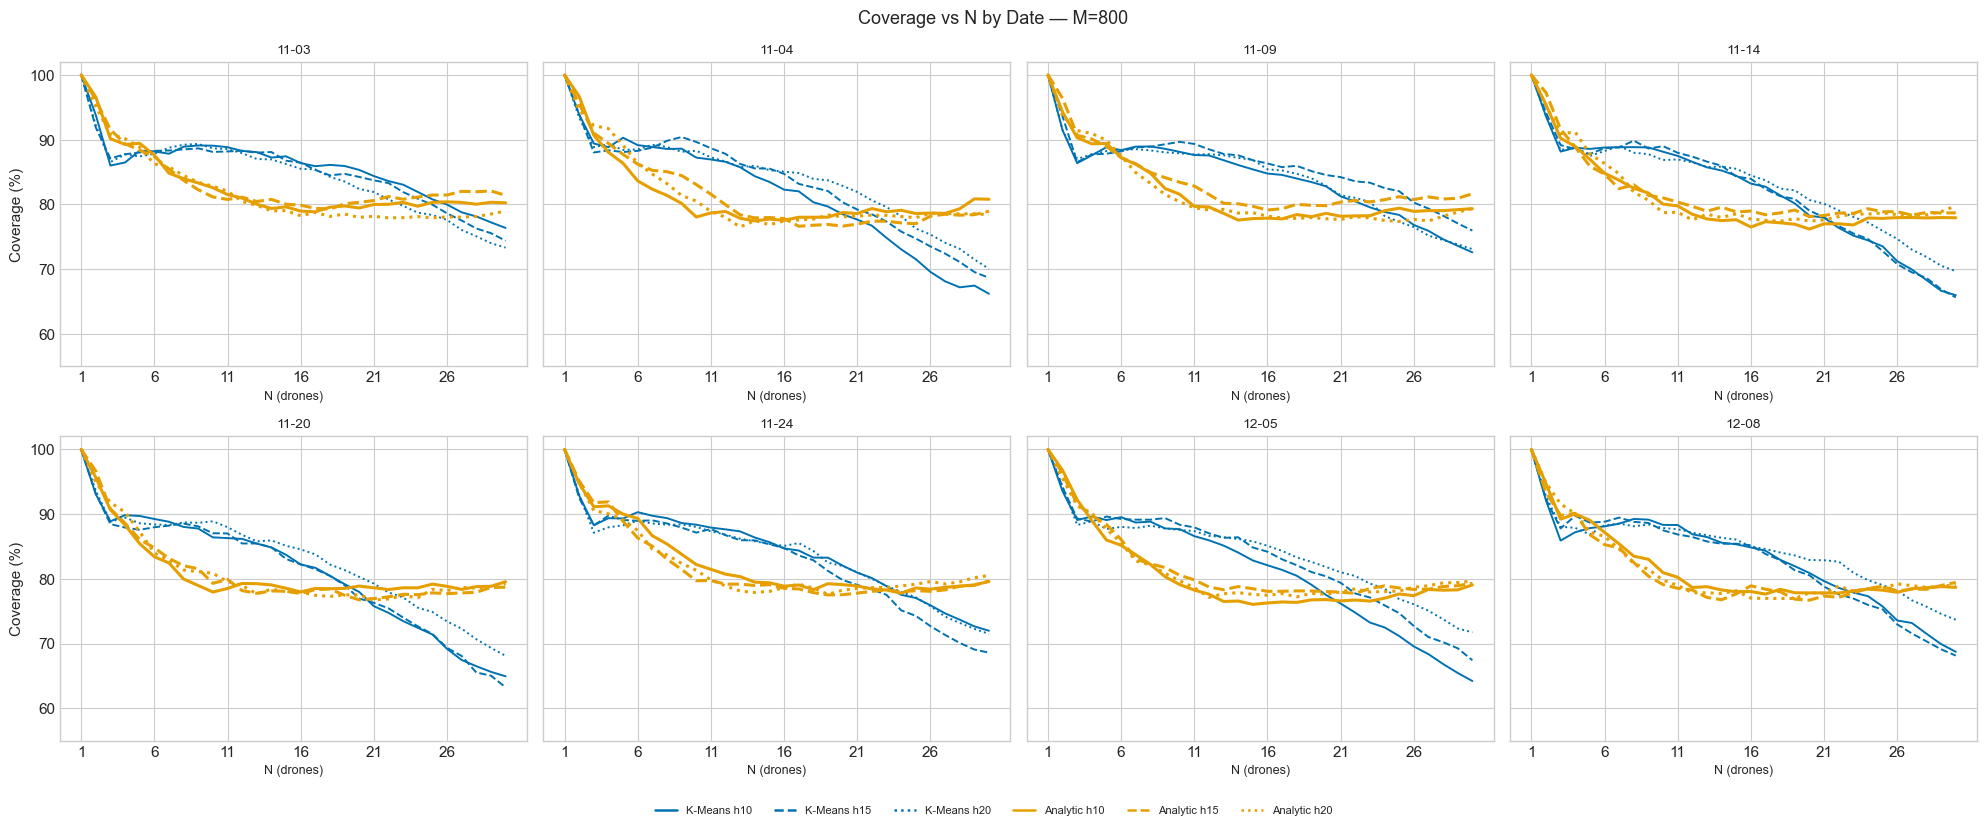

In [8]:
# Extract (date, hour) from snapshot labels
sub800_snap = sub800.copy()
sub800_snap["date"] = sub800_snap["snapshot"].str[:10]
sub800_snap["hour"] = sub800_snap["snapshot"].str.extract(r"_h(\d+)").astype(int)

dates = sorted(sub800_snap["date"].unique())
hours = sorted(sub800_snap["hour"].unique())
hour_colors = {h: c for h, c in zip(hours, ["#1f77b4", "#ff7f0e", "#2ca02c"])}
hour_ls     = {h: ls for h, ls in zip(hours, ["-", "--", ":"])}

fig, axes = plt.subplots(2, 4, figsize=(20, 8), sharey=True)

for ax, date in zip(axes.flat, dates):
    for method in METHODS:
        for hour in hours:
            snap_key = f"{date}_h{hour}"
            sub = sub800_snap[(sub800_snap["snapshot"] == snap_key) &
                              (sub800_snap["method"] == method)]
            if sub.empty:
                continue
            agg = sub.groupby("n_drones")["coverage_pct"].mean()
            lw = 2.2 if method == "analytic" else 1.4
            ax.plot(agg.index, agg.values,
                    color=METHOD_COLORS[method],
                    linestyle=hour_ls[hour], linewidth=lw,
                    label=f"{METHOD_LABELS[method]} h{hour:02d}")
    short_date = date.replace("2013-", "")
    ax.set_title(short_date, fontsize=10)
    ax.set_xlabel("N (drones)", fontsize=9)
    ax.set_xticks(range(1, 31, 5))
    ax.set_ylim(55, 102)

axes[0, 0].set_ylabel("Coverage (%)")
axes[1, 0].set_ylabel("Coverage (%)")

# Shared legend
handles = []
for method in METHODS:
    for hour in hours:
        h = plt.Line2D([0], [0], color=METHOD_COLORS[method], linestyle=hour_ls[hour],
                       linewidth=1.8, label=f"{METHOD_LABELS[method]} h{hour:02d}")
        handles.append(h)
fig.legend(handles=handles, loc="lower center", ncol=6, fontsize=8,
           bbox_to_anchor=(0.5, -0.04))

plt.suptitle(f"Coverage vs N by Date — M={M_MAIN}", fontsize=13)
plt.tight_layout()
plt.savefig("../results/telecom_coverage_by_date.pdf", bbox_inches="tight")
plt.show()

## 7. Summary Table — Key N Values, M=800 (averaged over 24 snapshots)

## Paper Figure — Coverage vs Drone Count (IEEE Style)

Publication-ready figure for the paper. IEEE conventions:
- Single-column width (3.5 in), serif font, 9 pt labels
- Color-blind friendly: blue + vermillion (Wong 2011 palette), triple-encoded with line style + marker
- Works in grayscale: solid/dashed lines with distinct markers
- Saved as PDF (vector) for LaTeX inclusion

Saved → ../results/fig_telecom_coverage_vs_N.pdf  and  ../paper/figures/fig_telecom_coverage_vs_N.pdf


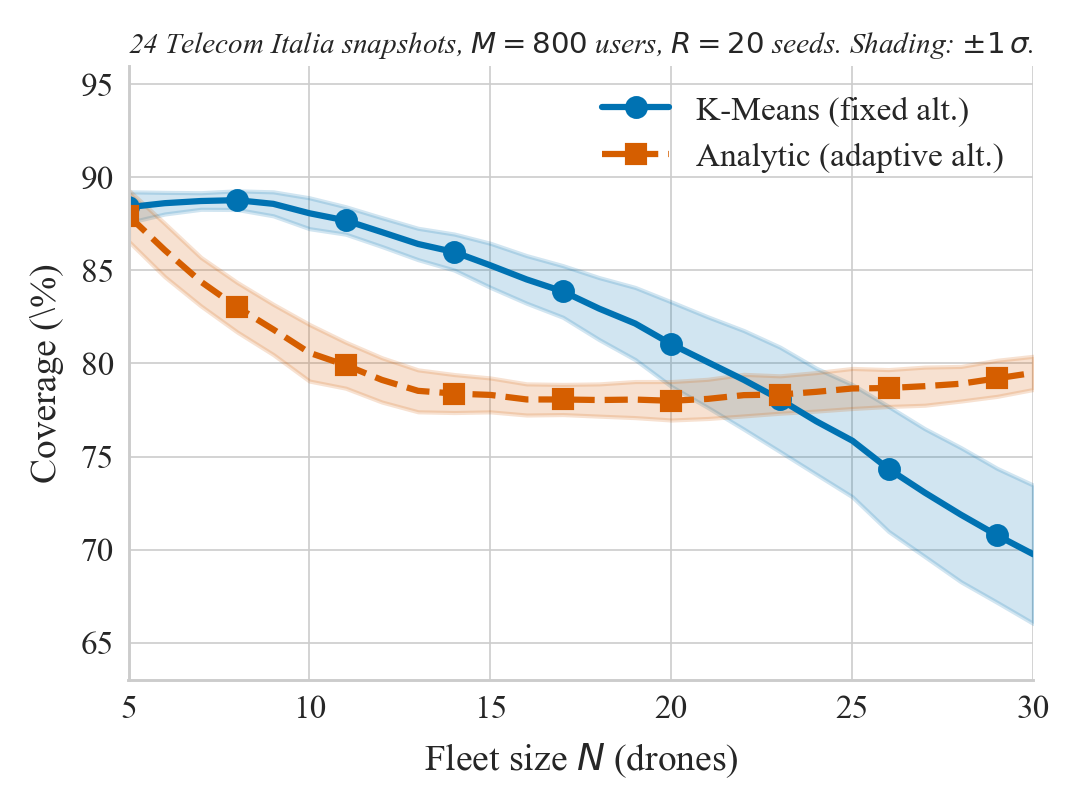

In [9]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ── IEEE style parameters ────────────────────────────────────────────────────
IEEE_W   = 3.5          # single-column width (inches)
IEEE_H   = 2.6          # height (inches)
FONT_SZ  = 9            # axis-label / legend font size
TICK_SZ  = 8            # tick-label font size
LW       = 1.5          # line width
MS       = 4.5          # marker size
ALPHA    = 0.18         # shading alpha

# Wong (2011) color-blind-safe palette
C_KM  = "#0072B2"   # blue      — K-Means  (solid,  circle)
C_AN  = "#D55E00"   # vermillion — Analytic (dashed, square)

matplotlib.rcParams.update({
    "font.family":      "serif",
    "font.serif":       ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size":        FONT_SZ,
    "axes.labelsize":   FONT_SZ,
    "axes.titlesize":   FONT_SZ,
    "xtick.labelsize":  TICK_SZ,
    "ytick.labelsize":  TICK_SZ,
    "legend.fontsize":  TICK_SZ,
    "lines.linewidth":  LW,
    "lines.markersize": MS,
    "axes.linewidth":   0.7,
    "grid.linewidth":   0.4,
    "grid.color":       "#cccccc",
    "figure.dpi":       300,
    "savefig.dpi":      300,
    "pdf.fonttype":     42,   # embeds fonts as Type 1 (IEEE requirement)
    "ps.fonttype":      42,
})

# ── Data: M=800, N≥5, averaged over 24 snapshots ────────────────────────────
sub    = df[df["m_users"] == 800]
grp_km = sub[sub["method"] == "kmeans"].groupby("n_drones")["coverage_pct"]
grp_an = sub[sub["method"] == "analytic"].groupby("n_drones")["coverage_pct"]

ns      = np.array([n for n in sorted(sub["n_drones"].unique()) if n >= 5])
km_mean = grp_km.mean().loc[ns].values
km_std  = grp_km.std().loc[ns].values
an_mean = grp_an.mean().loc[ns].values
an_std  = grp_an.std().loc[ns].values


# ── Figure ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(IEEE_W, IEEE_H))

# Shaded ±1 std bands
ax.fill_between(ns, km_mean - km_std, km_mean + km_std, color=C_KM, alpha=ALPHA)
ax.fill_between(ns, an_mean - an_std, an_mean + an_std, color=C_AN, alpha=ALPHA)

# Main lines — triple-encoded (color + line style + marker)
ax.plot(ns, km_mean, color=C_KM, linestyle="-",  marker="o",
        markevery=3, label="K-Means (fixed alt.)")
ax.plot(ns, an_mean, color=C_AN, linestyle="--", marker="s",
        markevery=3, label="Analytic (adaptive alt.)")

# Axes
ax.set_xlabel("Fleet size $N$ (drones)")
ax.set_ylabel("Coverage (\\%)")
ax.set_xlim(5, 30)
ax.set_ylim(63, 96)
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(5))
ax.grid(True, which="major", axis="y")

# Remove top/right spines (IEEE convention)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend
ax.legend(loc="upper right", framealpha=0.9, edgecolor="none")

ax.set_title(
    "24 Telecom Italia snapshots, $M=800$ users, $R=20$ seeds. Shading: $\\pm 1\\,\\sigma$.",
    fontsize=7, pad=3, style="italic",
)

plt.tight_layout(pad=0.4)

OUT     = Path("../results/fig_telecom_coverage_vs_N.pdf")
OUT_PAP = Path("../paper/figures/fig_telecom_coverage_vs_N.pdf")
OUT_PAP.parent.mkdir(parents=True, exist_ok=True)
for out in [OUT, OUT_PAP]:
    plt.savefig(out, bbox_inches="tight")
    plt.savefig(str(out).replace(".pdf", ".png"), bbox_inches="tight")
print(f"Saved → {OUT}  and  {OUT_PAP}")
plt.show()

# Restore notebook style for subsequent cells
plt.rcParams.update(plt.rcParamsDefault)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.size"] = 11

In [10]:
KEY_N_TABLE = [1, 2, 5, 8, 10, 15, 20, 23, 25, 30]

agg800 = (sub800.groupby(["n_drones", "method"])
          [["coverage_pct", "combined_score", "mean_sinr_db", "total_interference_dbm"]]
          .mean().round(2))

for metric in ["coverage_pct", "combined_score"]:
    print(f"\n{'='*70}")
    print(f"  {metric}  (mean over 24 snapshots, M=800)")
    print(f"{'='*70}")
    tbl = agg800[metric].unstack("method")[METHODS]
    tbl.columns = [METHOD_LABELS[m] for m in METHODS]
    tbl["Analytic − K-Means (pp)"] = (tbl["Analytic"] - tbl["K-Means"]).round(1)
    print(tbl.loc[KEY_N_TABLE].to_string())


  coverage_pct  (mean over 24 snapshots, M=800)
          K-Means  Analytic  Analytic − K-Means (pp)
n_drones                                            
1          100.00    100.00                      0.0
2           93.09     95.41                      2.3
5           88.39     87.94                     -0.5
8           88.77     83.02                     -5.8
10          88.06     80.57                     -7.5
15          85.27     78.31                     -7.0
20          81.03     77.99                     -3.0
23          78.07     78.33                      0.3
25          75.85     78.66                      2.8
30          69.75     79.49                      9.7

  combined_score  (mean over 24 snapshots, M=800)
          K-Means  Analytic  Analytic − K-Means (pp)
n_drones                                            
1            1.00      1.00                      0.0
2            0.95      0.97                      0.0
5            0.82      0.82                      0.0

## 8. User Distribution — Activity Crop & Sampled Positions (subset of 6 snapshots)

One representative snapshot per date-group (h10 entry) to show the spatial diversity
of the hottest crop across weeks and seasons.

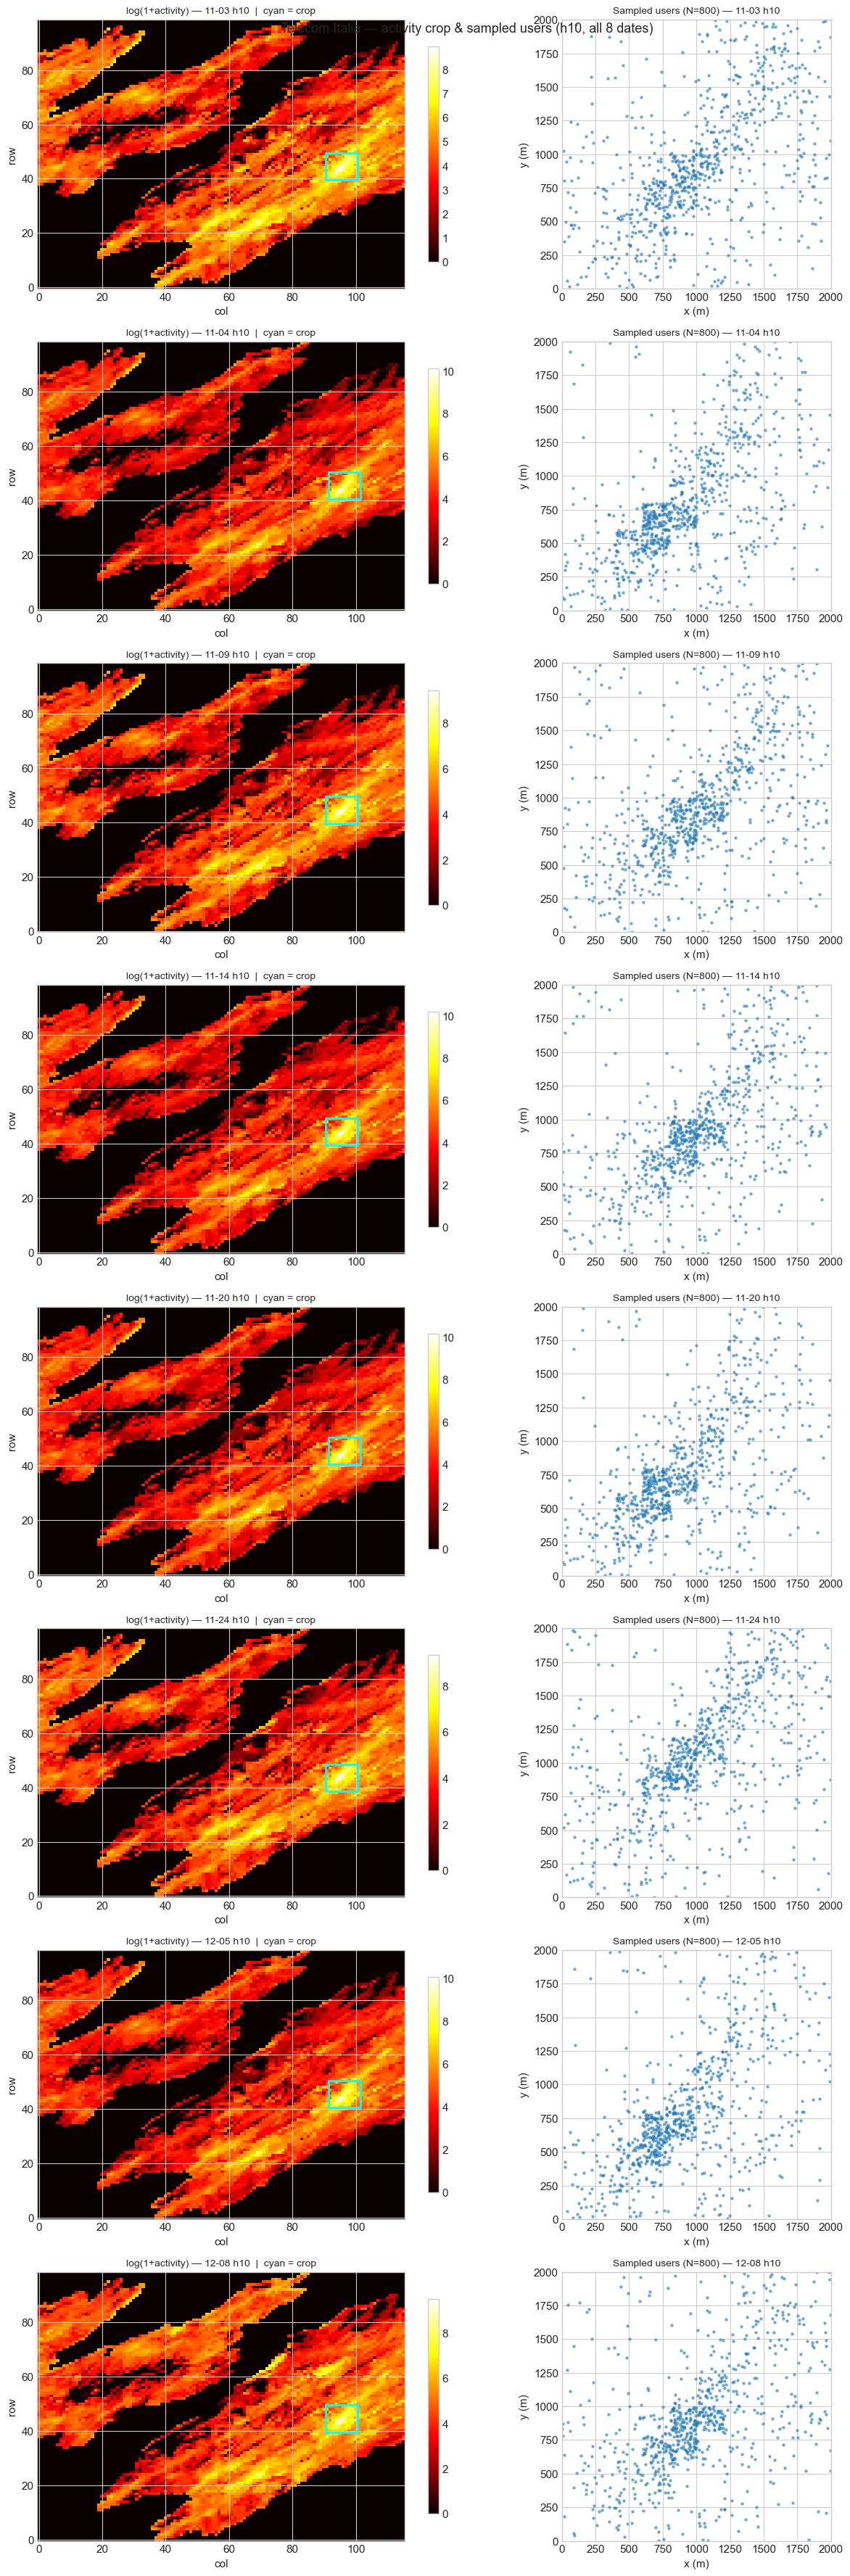

In [11]:
import sys
sys.path.insert(0, str(Path("../scripts").resolve()))
from extract_telecom_users import load_activity, sq_id_to_xy, find_hottest_crop

DATA_DIR   = Path("../dataverse_files")
CROP_CELLS = 10
AREA_SIZE  = 2000.0

# Show h10 snapshot for each of the 8 dates in the design
SHOW_DATES = ["2013-11-03", "2013-11-04", "2013-11-09", "2013-11-14",
              "2013-11-20", "2013-11-24", "2013-12-05", "2013-12-08"]
SHOW_HOUR  = 10

fig, axes = plt.subplots(len(SHOW_DATES), 2, figsize=(13, 4.5 * len(SHOW_DATES)))

for row_idx, date in enumerate(SHOW_DATES):
    label    = f"{date}_h{SHOW_HOUR}"
    npy_path = RESULTS_DIR / f"telecom_users_{label}_n800.npy"
    fpath    = DATA_DIR / f"sms-call-internet-tn-{date}.txt"

    activity             = load_activity(str(fpath), hour_utc=SHOW_HOUR)
    crop_row, crop_col   = find_hottest_crop(activity, CROP_CELLS)

    act_items = list(activity.items())
    rs   = [sq_id_to_xy(s)[0] for s, _ in act_items]
    cs   = [sq_id_to_xy(s)[1] for s, _ in act_items]
    vals = [v for _, v in act_items]
    grid = np.zeros((max(rs) + 1, max(cs) + 1))
    for r, c, v in zip(rs, cs, vals):
        grid[r, c] = v

    ax_l = axes[row_idx, 0]
    im   = ax_l.imshow(np.log1p(grid), origin="lower", cmap="hot", aspect="auto")
    rect = plt.Rectangle((crop_col - 0.5, crop_row - 0.5), CROP_CELLS, CROP_CELLS,
                          linewidth=2, edgecolor="cyan", facecolor="none")
    ax_l.add_patch(rect)
    ax_l.set_title(f"log(1+activity) — {date.replace('2013-','')} h{SHOW_HOUR:02d}  |  cyan = crop",
                   fontsize=10)
    ax_l.set_xlabel("col"); ax_l.set_ylabel("row")
    plt.colorbar(im, ax=ax_l, shrink=0.8)

    pos  = np.load(npy_path)
    ax_r = axes[row_idx, 1]
    ax_r.scatter(pos[:, 0], pos[:, 1], s=5, alpha=0.5, color="C0")
    ax_r.set_xlim(0, AREA_SIZE); ax_r.set_ylim(0, AREA_SIZE)
    ax_r.set_aspect("equal")
    ax_r.set_title(f"Sampled users (N={pos.shape[0]}) — {date.replace('2013-','')} h{SHOW_HOUR:02d}",
                   fontsize=10)
    ax_r.set_xlabel("x (m)"); ax_r.set_ylabel("y (m)")

plt.suptitle("Telecom Italia — activity crop & sampled users (h10, all 8 dates)", fontsize=13)
plt.tight_layout()
plt.savefig("../results/telecom_activity_maps.pdf", bbox_inches="tight")
plt.show()